In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import spacy
import glob
from constants import BASE_PATH
import json
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import text_cleaning as tc
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import itertools
from analysis_utils import *

In [3]:
from tqdm.auto import tqdm
tqdm.pandas()

In [4]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [5]:
from constants import (
    JIBARO_WORDS, GIBARO_WORDS, CAMPESINO_WORDS, 
    LCCN_TO_NAME, BASE_PATH
)

In [6]:
nlp = spacy.blank("es")

# Load Data

In [28]:
target_df = pd.read_pickle('prelim_analysis_target_records_df.pkl')

In [8]:
len(target_df)

15021

In [29]:
texts = []
cleaned_texts = []
for idx, r in target_df.iterrows():
    with open(f"{BASE_PATH}/{r['lccn']}/{r['year']}/{r['month']}/{r['day']}/{r['edition']}/{r['sequence']}/cleaned.json") as f:
        d = json.load(f)
        texts.append(list(zip(d['text_blocks_raw'], d['text_blocks_cleaned'])))

In [32]:
target_df['texts'] = texts
del texts
# One row per block
target_df = target_df.explode('texts')

In [43]:

target_df['text_raw'] = target_df['texts'].apply(lambda x: x[0]['text'])
target_df['text_cleaned'] = target_df['texts'].apply(lambda x: x[1]['text'])
target_df['text_id'] = target_df['texts'].apply(lambda x: x[0]['id'])
target_df['height'] = target_df['texts'].apply(lambda x: x[0]['height'])
target_df['width'] = target_df['texts'].apply(lambda x: x[0]['width'])
target_df['hpos'] = target_df['texts'].apply(lambda x: x[0]['hpos'])
target_df['vpos'] = target_df['texts'].apply(lambda x: x[0]['vpos'])
target_df['doc_cleaned'] = target_df['text_cleaned'].progress_apply(lambda x: nlp(x))

In [12]:
import gc
gc.collect()

18

In [13]:
target_df['contains_search_word_jibar'] = target_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, JIBARO_WORDS))
target_df['contains_search_word_gibar'] = target_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, GIBARO_WORDS))
target_df['contains_search_word_campesin'] = target_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, CAMPESINO_WORDS))
target_df['surrounding_text_jibar'] = target_df['doc_cleaned'].progress_apply(lambda x: get_surrounding_spans_as_doc(x, JIBARO_WORDS, 20))
target_df['surrounding_text_gibar'] = target_df['doc_cleaned'].progress_apply(lambda x: get_surrounding_spans_as_doc(x, GIBARO_WORDS, 20))
target_df['surrounding_text_campesino'] = target_df['doc_cleaned'].progress_apply(lambda x: get_surrounding_spans_as_doc(x, CAMPESINO_WORDS, 20))

  0%|          | 0/1158713 [00:00<?, ?it/s]

  0%|          | 0/1158713 [00:00<?, ?it/s]

  0%|          | 0/1158713 [00:00<?, ?it/s]

  0%|          | 0/1158713 [00:00<?, ?it/s]

  0%|          | 0/1158713 [00:00<?, ?it/s]

  0%|          | 0/1158713 [00:00<?, ?it/s]

In [15]:
len(target_df)

1158713

# Exclude irrelevant instances

## Build Training Dataset

In [ ]:
jibar_docs_df = target_df.loc[target_df['contains_search_word_jibar']].reset_index().set_index(['link', 'text_id'])
gibar_docs_df = target_df.loc[target_df['contains_search_word_gibar']].reset_index().set_index(['link', 'text_id'])

In [87]:
labels_data_df = pd.read_pickle('jibaro_gibaro_classification_labels_df.pkl')#.reset_index()

In [93]:
# labels_data_df['word_type'] = 'jibar'

In [88]:
labels_data = labels_data_df.to_dict('records')
processed_keys = set([(d['link'], d['text_id']) for d in labels_data])

In [90]:
# Use if labelling low confidence classifier labels
# pipeline_score = gibar_pipeline.predict_proba(gibar_docs_df)[:, 1] 
# idxs = np.array(gibar_docs_df.reset_index().loc[
#         (pipeline_score > 0.5) 
#         & (pipeline_score < 0.8) 
#     ].index)

# Use if labelling based on other keywords
vectorizer = CountVectorizer(tokenizer=spacy_tokenizer, lowercase=False, ngram_range=(1, 2), min_df=5)

tf_matrix = vectorizer.fit_transform(jibar_docs_df['doc_cleaned'].values).toarray()
tok_to_idx = {t: i for i, t in enumerate(vectorizer.get_feature_names_out())}
tf_matrix_surrounding = vectorizer.transform(jibar_docs_df['surrounding_text_jibar'])
idxs = np.argwhere(
    (tf_matrix_surrounding[:, tok_to_idx['amores']] > 0) #& 
    # (tf_matrix[:, tok_to_idx['jíbaro']] > 0) 
)
len(idxs)

4

In [91]:

to_label = [
    (jibar_docs_df.index[i][0], jibar_docs_df.index[i][1])
    for i in idxs.flatten()
]

In [92]:
jibar_docs_df['score'] = jibar_pipeline.predict_proba(jibar_docs_df)[:, 1]

In [93]:
for k in to_label:
    if k in processed_keys:
        continue
    print(k)
    print(jibar_docs_df.loc[k]['surrounding_text_jibar'])
    print("Score:", jibar_docs_df.loc[k]['score'])
    label = input("Label")
    if label == '-':
        continue
    labels_data.append({
        'link': k[0],
        'text_id': k[1],
        'label': int(label),
        # 'word_type': 'gibar'
        'word_type': 'jibar'
    })

('https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-08-14/ed-1/seq-2/', 'TB.0280.58')
.
y eso que, por discreción, no me
place revelar sus amores con las chicas
jíbaras, que más de una vez le aseguraron la suerte.
ah, mascotta!
veamos á 
Score: 0.3033111153117349


Label 0


('https://chroniclingamerica.loc.gov/lccn/sn86077151/1919-09-24/ed-1/seq-3/', 'P3_TB00011')
a aguí, ha venido ron
| dando su verso para la alegría de
| vivir de nuestros jíbaros, sus expansio-
' nes de tristeza o goce y sus manifesta-
| ciones de amores, 
Score: 0.2547002646906169


Label 0


In [478]:
# labels_data_df.to_pickle('jibaro_classification_labels_df.pkl')

In [94]:
pd.DataFrame.from_dict(labels_data).to_pickle('jibaro_gibaro_classification_labels_df.pkl')

In [ ]:
# labels_data_df.to_pickle('jibaro_classification_labels_df.pkl')

In [229]:
# idxs = [int(r[0]) for r in responses]
# y = [int(r[1]) for r in responses]
# X = tf_matrix[idxs,:]

# jibar_docs_surrounding = jibar_docs.iloc[idxs].apply(lambda x: get_surrounding_spans_as_doc(x, JIBARO_WORDS, 40))
# vectorizer2 = CountVectorizer(tokenizer=spacy_tokenizer, lowercase=False, ngram_range=(1, 2), min_df=2)
# X2 = vectorizer2.fit_transform(jibar_docs_surrounding.values).toarray()

# len(responses)


## Build Model

In [16]:
labels_data_df = pd.read_pickle('jibaro_gibaro_classification_labels_df.pkl').set_index(['link', 'text_id'])
target_df = target_df.reset_index().set_index(['link', 'text_id'])
labels_data_df = pd.merge(labels_data_df, target_df, left_index=True, right_index=True)
labels_data_df.head(10)

,,level_0,index,label,word_type,lccn,date,year,month,day,edition,...,text_raw,text_cleaned,height,width,hpos,vpos,doc_cleaned,surrounding_text_jibar,surrounding_text_gibar,surrounding_text_campesino
link,text_id,,,,,,,,,,,,,,,,,,,,,
https://chroniclingamerica.loc.gov/lccn/sn91099739/1876-02-16/ed-1/seq-3/,P3_TB00001,0.0,0.0,0,jibar,sn91099739,1876-02-16,1876,02,16,ed-1,...,"se encontraba en Flor del Cayo, acü- J\ndió se...","se encontraba en flor del cayo, acü- j\ndió se...",26759,3298,1115,1531,"(se, encontraba, en, flor, del, cayo, ,, acü-,...","(1, \n, de, su, teniente, coronel, d., josé, p...",(),()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1878-05-03/ed-1/seq-4/,P4_TB00001,1.0,1.0,1,jibar,sn91099739,1878-05-03,1878,05,03,ed-1,...,EirfiiSA II T&PQRIS ESniSLES.\nCORREOS DE LAS ...,eirfiisa ii t&pqris esnisles.\ncorreos de las ...,15236,2670,883,2414,"(eirfiisa, ii, t&pqris, esnisles, ., \n, corre...",(),"(saldrá, do, la, \n, ualiana, y, uceará, 4, k,...",()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1879-11-23/ed-1/seq-3/,P3_TB00008,2.0,2.0,0,jibar,sn91099739,1879-11-23,1879,11,23,ed-1,...,"seis hombres, hiriendo á uno de ellos y\nlogra...","seis hombres, hiriendo á uno de ellos y\nlogra...",14500,2731,8872,1450,"(seis, hombres, ,, hiriendo, á, uno, de, ellos...","(,, recibidas, por, \n, telégrafo, ,, un, indi...",(),()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1877-12-05/ed-1/seq-3/,P3_TB00007,3.0,3.0,0,jibar,sn91099739,1877-12-05,1877,12,05,ed-1,...,L>s talleres de costura do Puerto\nPrincipe en...,l>s talleres de costura do puerto\nprincipe en...,18501,2604,6241,7857,"(l, >, s, talleres, de, costura, do, puerto, \...","(\n, las, noticias, de, estos, últimos, dias, ...",(),()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1880-05-09/ed-1/seq-4/,P4_TB00003,4.0,4.0,1,jibar,sn91099739,1880-05-09,1880,05,09,ed-1,...,an iim nan-nutlt\nRUTA DEL VAPOR ESPASOL\nwßan...,an iim nan-nutlt\nruta del vapor espasol\nwßan...,18931,2863,7460,1162,"(an, iim, nan-nutlt, \n, ruta, del, vapor, esp...",(),"(los, demás, \n, jtasaje, entero, ., \n, servi...",()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1880-02-08/ed-1/seq-4/,P4_TB00006,5.0,5.0,1,jibar,sn91099739,1880-02-08,1880,02,08,ed-1,...,VAFüiiES - Co¡í!!Lv3 HAÜiIUNW\nDE A. LOPEZ Y C...,vafüiies - co¡í!!lv3 haüiiunw\nde a. lopez y c...,18128,2858,7115,10620,"(vafüiies, -, co¡í!!lv3, haüiiunw, \n, de, a.,...",(),"(v, %, do, rebajis, \n, mmi, ge, u, habana, i,...",()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1880-02-13/ed-1/seq-3/,P3_TB00021,6.0,6.0,0,jibar,sn91099739,1880-02-13,1880,02,13,ed-1,...,Desgracia.—Parece que el otro dia en\nel Dorad...,desgracia.—parece que el otro dia en\nel dorad...,9213,2864,15562,7847,"(desgracia, ., —parece, que, el, otro, dia, en...","(literarios, en, honor, dol, malogrado, gautie...",(),()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1880-06-09/ed-1/seq-4/,P4_TB00001,7.0,7.0,1,jibar,sn91099739,1880-06-09,1880,06,09,ed-1,...,wv**-' ' 1\nSIHiSiIU liÉtt ¡ftIJUS\nCORREOS DE...,v**-' ' 1\nsihisiiu liétt ¡ftijus\ncorreos de ...,27033,2920,1318,1852,"(v**-, ', ', 1, \n, sihisiiu, liétt, ¡, ftijus...",(),"(illa, mil, ., \n, fli, .ii, a, n.ii'vltab, e....",()
https://chroniclingamerica.loc.gov/lccn/sn86077151/1923-11-05/ed-1/seq-2/,P2_TB00001,8.0,8.0,0,jibar,sn86077151,1923-11-05,1923,11,05,ed-1,...,ae S Te D S E TA\nEL MINDO\n¿¿VERBA_Q! Y Jº» ¿...,ae s te d s e ta\nel mindo\n¿¿verbal! y jº» ¿e...,22970,2769,647,1148,"(ae, s, te, d, s, e, ta, \n, el, mindo, \n, ¿,...","(artistas, \n, ', ”, …, ', y, ., “, -$s, ., …,...",(),()


In [17]:
labels_data_df = pd.read_pickle('jibaro_gibaro_classification_labels_df.pkl').set_index(['link', 'text_id'])
target_df = target_df.reset_index().set_index(['link', 'text_id'])
labels_data_df = pd.merge(labels_data_df, target_df, left_index=True, right_index=True)
labels_data_df.head(10)

,,level_0,index,label,word_type,lccn,date,year,month,day,edition,...,text_raw,text_cleaned,height,width,hpos,vpos,doc_cleaned,surrounding_text_jibar,surrounding_text_gibar,surrounding_text_campesino
link,text_id,,,,,,,,,,,,,,,,,,,,,
https://chroniclingamerica.loc.gov/lccn/sn91099739/1876-02-16/ed-1/seq-3/,P3_TB00001,0.0,0.0,0,jibar,sn91099739,1876-02-16,1876,02,16,ed-1,...,"se encontraba en Flor del Cayo, acü- J\ndió se...","se encontraba en flor del cayo, acü- j\ndió se...",26759,3298,1115,1531,"(se, encontraba, en, flor, del, cayo, ,, acü-,...","(1, \n, de, su, teniente, coronel, d., josé, p...",(),()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1878-05-03/ed-1/seq-4/,P4_TB00001,1.0,1.0,1,jibar,sn91099739,1878-05-03,1878,05,03,ed-1,...,EirfiiSA II T&PQRIS ESniSLES.\nCORREOS DE LAS ...,eirfiisa ii t&pqris esnisles.\ncorreos de las ...,15236,2670,883,2414,"(eirfiisa, ii, t&pqris, esnisles, ., \n, corre...",(),"(saldrá, do, la, \n, ualiana, y, uceará, 4, k,...",()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1879-11-23/ed-1/seq-3/,P3_TB00008,2.0,2.0,0,jibar,sn91099739,1879-11-23,1879,11,23,ed-1,...,"seis hombres, hiriendo á uno de ellos y\nlogra...","seis hombres, hiriendo á uno de ellos y\nlogra...",14500,2731,8872,1450,"(seis, hombres, ,, hiriendo, á, uno, de, ellos...","(,, recibidas, por, \n, telégrafo, ,, un, indi...",(),()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1877-12-05/ed-1/seq-3/,P3_TB00007,3.0,3.0,0,jibar,sn91099739,1877-12-05,1877,12,05,ed-1,...,L>s talleres de costura do Puerto\nPrincipe en...,l>s talleres de costura do puerto\nprincipe en...,18501,2604,6241,7857,"(l, >, s, talleres, de, costura, do, puerto, \...","(\n, las, noticias, de, estos, últimos, dias, ...",(),()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1880-05-09/ed-1/seq-4/,P4_TB00003,4.0,4.0,1,jibar,sn91099739,1880-05-09,1880,05,09,ed-1,...,an iim nan-nutlt\nRUTA DEL VAPOR ESPASOL\nwßan...,an iim nan-nutlt\nruta del vapor espasol\nwßan...,18931,2863,7460,1162,"(an, iim, nan-nutlt, \n, ruta, del, vapor, esp...",(),"(los, demás, \n, jtasaje, entero, ., \n, servi...",()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1880-02-08/ed-1/seq-4/,P4_TB00006,5.0,5.0,1,jibar,sn91099739,1880-02-08,1880,02,08,ed-1,...,VAFüiiES - Co¡í!!Lv3 HAÜiIUNW\nDE A. LOPEZ Y C...,vafüiies - co¡í!!lv3 haüiiunw\nde a. lopez y c...,18128,2858,7115,10620,"(vafüiies, -, co¡í!!lv3, haüiiunw, \n, de, a.,...",(),"(v, %, do, rebajis, \n, mmi, ge, u, habana, i,...",()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1880-02-13/ed-1/seq-3/,P3_TB00021,6.0,6.0,0,jibar,sn91099739,1880-02-13,1880,02,13,ed-1,...,Desgracia.—Parece que el otro dia en\nel Dorad...,desgracia.—parece que el otro dia en\nel dorad...,9213,2864,15562,7847,"(desgracia, ., —parece, que, el, otro, dia, en...","(literarios, en, honor, dol, malogrado, gautie...",(),()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1880-06-09/ed-1/seq-4/,P4_TB00001,7.0,7.0,1,jibar,sn91099739,1880-06-09,1880,06,09,ed-1,...,wv**-' ' 1\nSIHiSiIU liÉtt ¡ftIJUS\nCORREOS DE...,v**-' ' 1\nsihisiiu liétt ¡ftijus\ncorreos de ...,27033,2920,1318,1852,"(v**-, ', ', 1, \n, sihisiiu, liétt, ¡, ftijus...",(),"(illa, mil, ., \n, fli, .ii, a, n.ii'vltab, e....",()
https://chroniclingamerica.loc.gov/lccn/sn86077151/1923-11-05/ed-1/seq-2/,P2_TB00001,8.0,8.0,0,jibar,sn86077151,1923-11-05,1923,11,05,ed-1,...,ae S Te D S E TA\nEL MINDO\n¿¿VERBA_Q! Y Jº» ¿...,ae s te d s e ta\nel mindo\n¿¿verbal! y jº» ¿e...,22970,2769,647,1148,"(ae, s, te, d, s, e, ta, \n, el, mindo, \n, ¿,...","(artistas, \n, ', ”, …, ', y, ., “, -$s, ., …,...",(),()


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.svm import LinearSVC
from sklearn.metrics import make_scorer, f1_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_validate

In [17]:

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf_doc_cleaned', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, min_df=2), 'doc_cleaned'),
        ('tfidf_surrounding_jibar', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, ngram_range=(1, 2), min_df=2), 'surrounding_text_jibar'),
        ('tfidf_surrounding_gibar', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, ngram_range=(1, 2), min_df=2), 'surrounding_text_gibar')
    ],
    remainder='drop'
)

base_svm = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=20000
)

calibrated_svm = CalibratedClassifierCV(
    estimator=base_svm,
    method="sigmoid",   # Platt scaling
    cv=5,
)

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('calibrated_svm', calibrated_svm),
    ]
)


In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = cross_validate(
    pipeline,
    X=labels_data_df,
    y=labels_data_df['label'],
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1,
)

print({k: np.mean(v) for k, v in results.items() if k.startswith("test_")})

{'test_accuracy': np.float64(0.9318181818181819), 'test_precision': np.float64(0.965385885813306), 'test_recall': np.float64(0.9331073446327685), 'test_f1': np.float64(0.9489145453166434), 'test_roc_auc': np.float64(0.9776988533578248)}


In [81]:
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf_doc_cleaned', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, min_df=2), 'doc_cleaned'),
        ('tfidf_surrounding_jibar', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, ngram_range=(1, 2), min_df=2), 'surrounding_text_jibar')
    ],
    remainder='drop'
)

calibrated_svm = CalibratedClassifierCV(
    estimator=base_svm,
    method="sigmoid",   # Platt scaling
    cv=5,
)

selected_labels_df = labels_data_df.loc[labels_data_df['word_type'] == 'jibar']
jibar_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('calibrated_svm', calibrated_svm),
    ]
)

jibar_pipeline.fit(selected_labels_df, selected_labels_df['label'])

,steps,"[('preprocessor', ...), ('calibrated_svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tfidf_doc_cleaned', ...), ('tfidf_surrounding_jibar', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
selected_labels_df = labels_data_df.loc[labels_data_df['word_type'] == 'gibar']

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf_doc_cleaned', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, min_df=2), 'doc_cleaned'),
        ('tfidf_surrounding_gibar', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, ngram_range=(1, 2), min_df=2), 'surrounding_text_gibar')
    ],
    remainder='drop'
)

calibrated_svm = CalibratedClassifierCV(
    estimator=base_svm,
    method="sigmoid",   # Platt scaling
    cv=5,
)


gibar_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('calibrated_svm', calibrated_svm),
    ]
)

gibar_pipeline.fit(selected_labels_df, selected_labels_df['label'])

,steps,"[('preprocessor', ...), ('calibrated_svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tfidf_doc_cleaned', ...), ('tfidf_surrounding_gibar', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [325]:
pred_y = gibar_pipeline.predict_proba(labels_data_df)[:, 1]

(array([ 21.,  17.,   1.,   0.,   0.,   0.,   3.,  52.,  75., 271.]),
 array([0.01295851, 0.11143122, 0.20990393, 0.30837665, 0.40684936,
        0.50532207, 0.60379479, 0.7022675 , 0.80074021, 0.89921292,
        0.99768564]),
 <BarContainer object of 10 artists>)

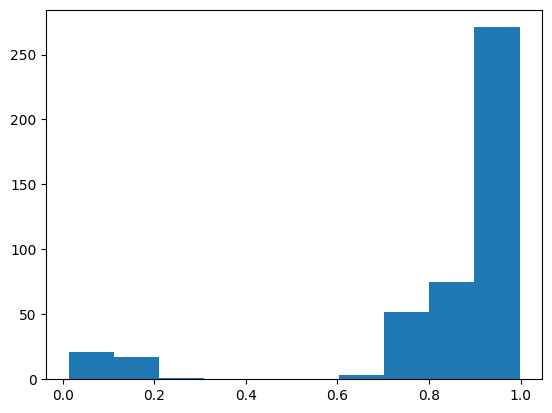

In [326]:
plt.hist(pred_y)

In [360]:
with open('models/jibar_pipeline.pkl', 'wb') as f:
    pickle.dump(jibar_pipeline, f)

with open('models/gibar_pipeline.pkl', 'wb') as f:
    pickle.dump(gibar_pipeline, f)

In [10]:
with open('models/jibar_pipeline.pkl', 'rb') as f:
    jibar_pipeline = pickle.load(f)

with open('models/gibar_pipeline.pkl', 'rb') as f:
    gibar_pipeline = pickle.load(f)

# Label with Model and Annotations

In [20]:
labels_data_df = pd.read_pickle('jibaro_gibaro_classification_labels_df.pkl')
labels_data_df = labels_data_df[['link', 'text_id', 'word_type', 'label']].drop_duplicates().set_index(['link', 'text_id'])
if 'level_0' in labels_data_df.columns:
    del labels_data_df['level_0']
target_df = target_df.reset_index().set_index(['link', 'text_id'])
data_df = target_df.join(labels_data_df, how='left')

In [21]:
scores = gibar_pipeline.predict_proba(data_df)[:, 1]
data_df['relvent_gibar_doc_score'] =  scores

In [22]:
scores = jibar_pipeline.predict_proba(data_df)[:, 1]
data_df['relvent_jibar_doc_score'] =  scores

In [23]:
data_df['relevant_jibar_doc'] = data_df.apply(
    lambda r: (r['label'] == 0) if pd.notna(r['label']) else (r['contains_search_word_jibar'] > 0) and (r['relvent_jibar_doc_score'] < 0.5), 
    axis=1
)

In [24]:
data_df['relevant_gibar_doc'] = data_df.apply(
    lambda r: (r['label'] == 0) if pd.notna(r['label']) else (r['contains_search_word_gibar'] > 0) and (r['relvent_gibar_doc_score'] < 0.5), 
    axis=1
)

In [25]:
data_df['relevant_campesin_doc'] = (data_df['contains_search_word_campesin'] > 0)

In [26]:
data_df['relevant_jibar_doc'].sum(), data_df['relevant_gibar_doc'].sum(), data_df['relevant_campesin_doc'].sum()

(np.int64(2164), np.int64(136), np.int64(6226))

In [27]:
data_df.sample(3)

,,lccn,date,year,month,day,edition,sequence,total_tokens,title,jibaro_counts,...,surrounding_text_jibar,surrounding_text_gibar,surrounding_text_campesino,word_type,label,relvent_gibar_doc_score,relvent_jibar_doc_score,relevant_jibar_doc,relevant_gibar_doc,relevant_campesin_doc
link,text_id,,,,,,,,,,,,,,,,,,,,,
https://chroniclingamerica.loc.gov/lccn/sn91099747/1909-10-10/ed-1/seq-4/,TB.0309a.184,sn91099747,1909-10-10,1909,10,10,ed-1,seq-4,5585,La correspondencia de Puerto Rico,0,...,(),(),(),NaN,NaN,0.710735,0.502402,False,False,False
https://chroniclingamerica.loc.gov/lccn/sn90070270/1896-07-21/ed-1/seq-2/,TB.0400.185,sn90070270,1896-07-21,1896,07,21,ed-1,seq-2,5093,La democracia,0,...,(),(),(),NaN,NaN,0.864985,0.402692,False,False,False
https://chroniclingamerica.loc.gov/lccn/sn91099747/1897-11-17/ed-1/seq-2/,TB.0316.214,sn91099747,1897-11-17,1897,11,17,ed-1,seq-2,7337,La correspondencia de Puerto Rico,0,...,(),(),(),NaN,NaN,0.822770,0.451606,False,False,False


In [67]:
data_df['relevant_jibar_doc'].sum(), data_df['relevant_gibar_doc'].sum(), data_df['relevant_campesin_doc'].sum()

(np.int64(1837), np.int64(131), np.int64(5378))

In [30]:
data_df['contains_search_word_jibar'] = data_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, JIBARO_WORDS))
data_df['contains_search_word_gibar'] = data_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, GIBARO_WORDS))
data_df['contains_search_word_campesin'] = data_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, CAMPESINO_WORDS))


  0%|          | 0/1158714 [00:00<?, ?it/s]

  0%|          | 0/1158714 [00:00<?, ?it/s]

  0%|          | 0/1158714 [00:00<?, ?it/s]

In [31]:
data_df['surrounding_text_campesino'] = data_df['doc_cleaned'].progress_apply(lambda x: get_surrounding_spans_as_doc(x, CAMPESINO_WORDS, 20))

  0%|          | 0/1158714 [00:00<?, ?it/s]

In [32]:
data_df['doc_length'] = data_df['doc_cleaned'].progress_apply(len)

  0%|          | 0/1158714 [00:00<?, ?it/s]

In [33]:
data_df['is_relevant'] = data_df['relevant_jibar_doc'] | data_df['relevant_gibar_doc'] | data_df['relevant_campesin_doc']

In [34]:
data_df = data_df.reset_index()

In [34]:
data_df.loc[data_df['is_relevant']].to_pickle('relevant_docs_df.pkl')

# Analyze Removed Texts

In [45]:
labels_data_df = pd.read_pickle('jibaro_gibaro_classification_labels_df.pkl').set_index(['link', 'text_id'])
target_df = target_df.reset_index().set_index(['link', 'text_id'])
labels_data_df = pd.merge(labels_data_df, target_df, left_index=True, right_index=True)


In [51]:
for t in labels_data_df.loc[labels_data_df['label'] == 1]['text_cleaned'].sample(20).values:
    print(t[:500])
    print('~~~~')

espectaculos para hoy |
cine tres banderas. “ei
gran cocinero.” y el 11 y 12 episodios de “la ratera relámpa-
-50.” al i
| mañana, “asesino ¡soc“orro![
policía”, cómica. “el despertar
de un alma”, en cinco partes. - |
' cine. luna. “cásate y ve-
'po'r metralla. * ¿ l
rás”, y “el terror de la sierra”,
mañana, “el sello gris”, y por
mono.” ea l
la noche -“tarzan o el hombre
lunes, la segunda parte de
“tarzán o el hombre mono”...
cine habana.—“ una idea feliz”s ...
retreta.—concierto popular el
dom
~~~~
salida.
i>e la habana ed penúltimo dia de cada mes.
de su evitas el 1
gibara cí... ... 2
santgo de ciiliit. ó
“ mavagüez h
puerto-rico.... 13
'• ronce si
“ la guaira !7i
“ puerto cabello.. 1h
*• sabanilla 211
*• cartagena -j
~~~~
a
do cada mes y alguno de la comerá
rv-nr nal jo i 1 x 1 j a 1
para la peninsula
6 los gas kilos.
l " 1000 küos ($8 para barcelona
$8 los 625 kilos.
fio loa 1000 tilo.
de puerto-rico.
viaje de regreso.
fiaban a
volantsri...
3
gibara
eventual...
ponce
volontaria...